# Yelp sentiment classification

Srinidhi, SID4 2342. This notebook defaults to **CPU smoke verification**. Its small synthetic outputs are not final lab results. Review the source and configuration before full training. Every run writes raw logs, provenance, metrics, outputs, and checkpoints to a new folder.

In [1]:
SID4 = 2342
SEED = SID4
SLICE = SID4 % 1000
HP_ID = SID4 % 6
CLS_A = SID4 % 10
CLS_B = (CLS_A + 1 + ((SID4 // 10) % 9)) % 10
print(dict(SID4=SID4, SEED=SEED, SLICE=SLICE, HP_ID=HP_ID, CLS_A=CLS_A, CLS_B=CLS_B))

{'SID4': 2342, 'SEED': 2342, 'SLICE': 342, 'HP_ID': 2, 'CLS_A': 2, 'CLS_B': 3}


In [2]:
from pathlib import Path
import os
import sys
roots = [Path.cwd(), *Path.cwd().parents]
ROOT = next((p for p in roots if (p / "src/lab1").is_dir() and (p / "pyproject.toml").is_file()), None)
if ROOT is None:
    raise RuntimeError("Extract the complete package and start this notebook inside its folder.")
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))
from lab1.common import environment, utc_now
from lab1.run import execute
print(environment())

{'captured_utc': '2026-09-18T22:31:24.186063+00:00', 'python': '3.12.14', 'platform': 'macOS-27.0-arm64-arm-64bit', 'machine': 'arm64', 'packages': {'torch': '2.11.0', 'torchvision': '0.26.0', 'numpy': '2.5.3', 'pandas': '3.0.6', 'scikit-learn': '1.9.1', 'scipy': '1.16.3', 'matplotlib': '3.11.2', 'datasets': '5.0.1', 'Pillow': '12.3.0', 'clean-fid': '0.1.35', 'lpips': '0.1.4', 'prdc': '0.2'}, 'cuda_available': False, 'cuda_build': None, 'cudnn': None, 'gpus': [], 'mps_available': True}


In [3]:
TASK = "sentiment"
MODE = "smoke"  # "rehearsal" is short; "full" selects the complete training configuration.
DEVICE = "cpu"  # Change to "cuda" on RunPod or the college NVIDIA machine.
OVERRIDES = []  # See task README for actual image-data paths and optional overrides.
OUTPUT = Path("reproducibility/raw_logs/srinidhi") / ("notebook-" + MODE + "-" + utc_now().replace(":", "-")) / TASK
print({"task": TASK, "mode": MODE, "device": DEVICE, "output": str(OUTPUT)})

{'task': 'sentiment', 'mode': 'smoke', 'device': 'cpu', 'output': 'reproducibility/raw_logs/srinidhi/notebook-smoke-2026-09-18T22-31-24.196483+00-00/sentiment'}


In [4]:
result = execute(TASK, MODE, OUTPUT, DEVICE, overrides=OVERRIDES)
result["summary"]

{"event": "start", "task": "sentiment", "mode": "smoke", "utc": "2026-09-18T22:31:24.210780+00:00", "device": "cpu"}


sentiment/maxpool_mlp epoch=1 train_loss=0.6551 val_macro_f1=0.6571


sentiment/bilstm epoch=1 train_loss=0.6949 val_macro_f1=0.3333


sentiment/dilated_cnn epoch=1 train_loss=0.6704 val_macro_f1=0.3333


{"event": "completed", "task": "sentiment", "mode": "smoke", "elapsed_seconds": 2.6425223749974975}


{'mode': 'smoke',
 'synthetic': True,
 'models': {'maxpool_mlp': {'count': 16,
   'accuracy': 0.625,
   'mcc': 0.2581988897471611,
   'brier': 0.23735546769620058,
   'confusion_matrix': [[4, 4], [2, 6]],
   'threshold': 0.5,
   'macro': {'precision': 0.6333333333333333,
    'recall': 0.625,
    'f1': 0.6190476190476191},
   'micro': {'precision': 0.625, 'recall': 0.625, 'f1': 0.625},
   'weighted': {'precision': 0.6333333333333333,
    'recall': 0.625,
    'f1': 0.6190476190476191},
   'per_class': [{'label': 0,
     'precision': 0.6666666666666666,
     'recall': 0.5,
     'f1': 0.5714285714285714,
     'support': 8},
    {'label': 1,
     'precision': 0.6,
     'recall': 0.75,
     'f1': 0.6666666666666666,
     'support': 8}],
   'ece_15': 0.24777169711887834,
   'ece_definition': 'Top-label confidence ECE; 15 equal-width bins on [0,1]; threshold 0.5.',
   'roc_auc': 0.78125,
   'pr_auc_trapezoidal': 0.8426913364413364,
   'bootstrap_95_percentile': {'accuracy': {'low': 0.5,
     '

bilstm/confusion_matrix.png


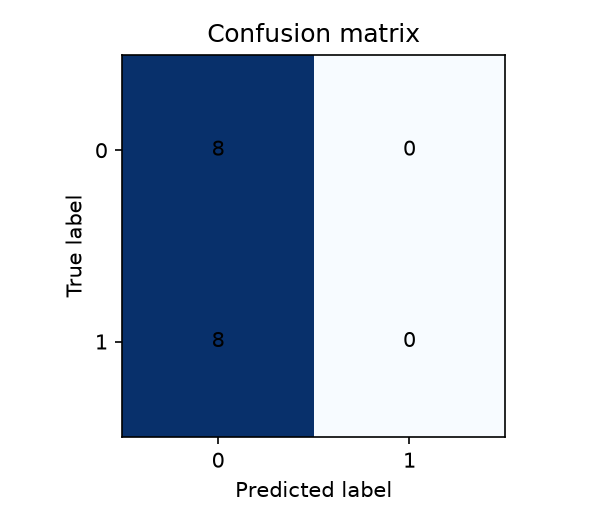

bilstm/evaluation_curves.png


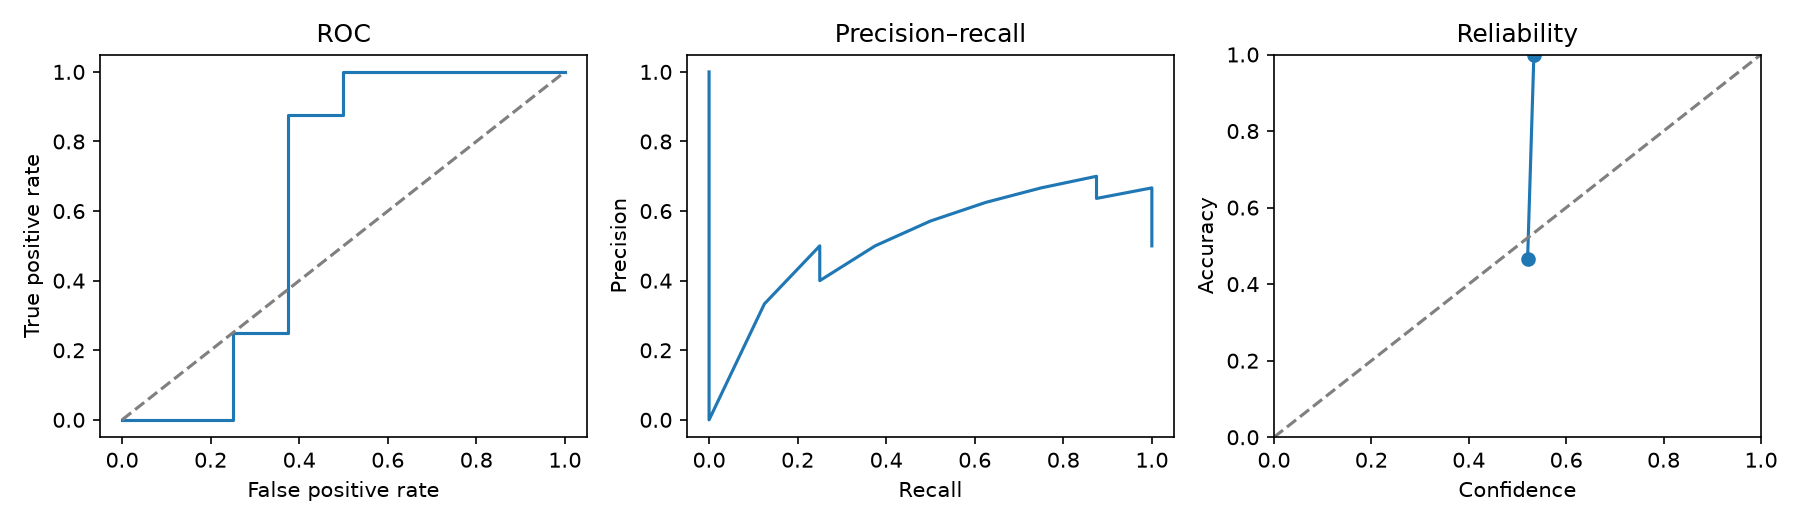

bilstm/learning_curves.png


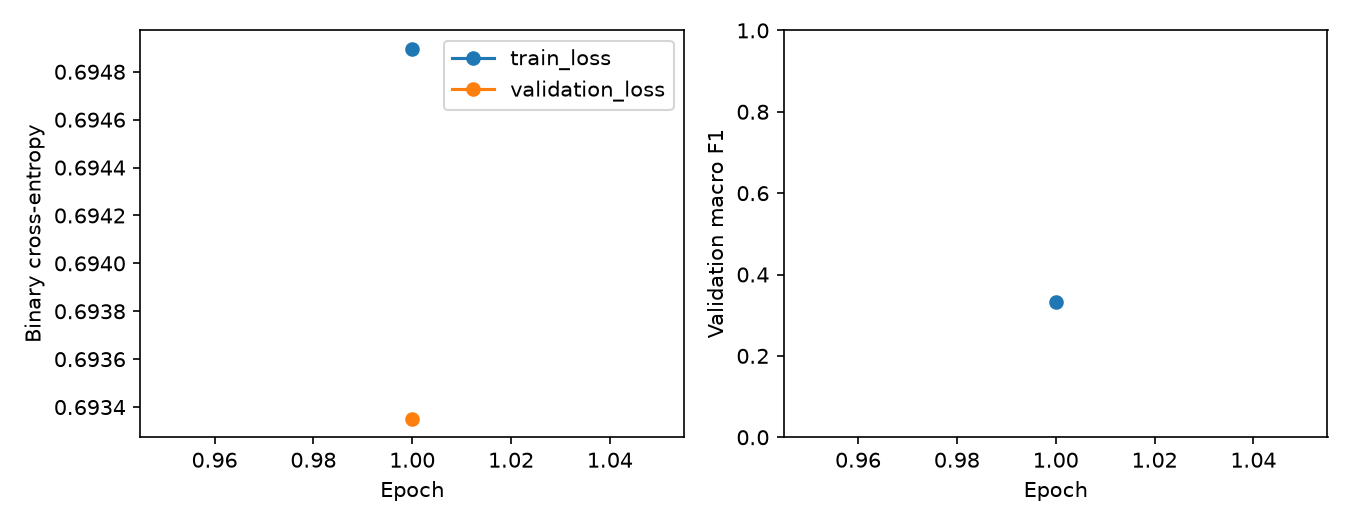

dilated_cnn/confusion_matrix.png


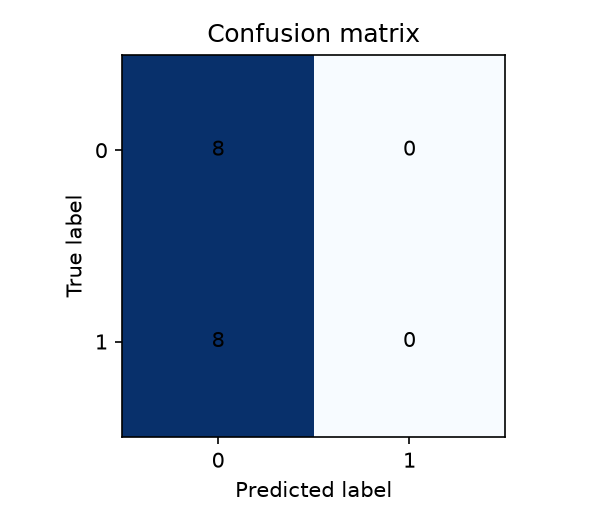

dilated_cnn/evaluation_curves.png


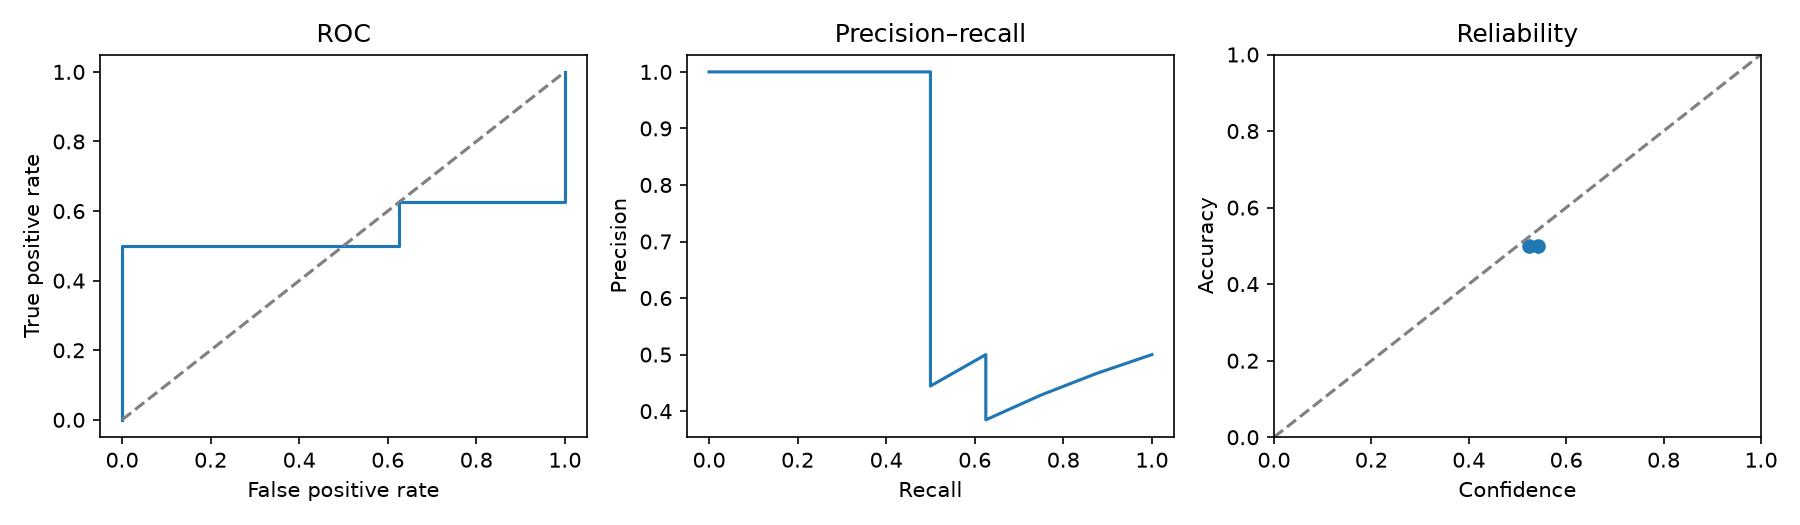

dilated_cnn/learning_curves.png


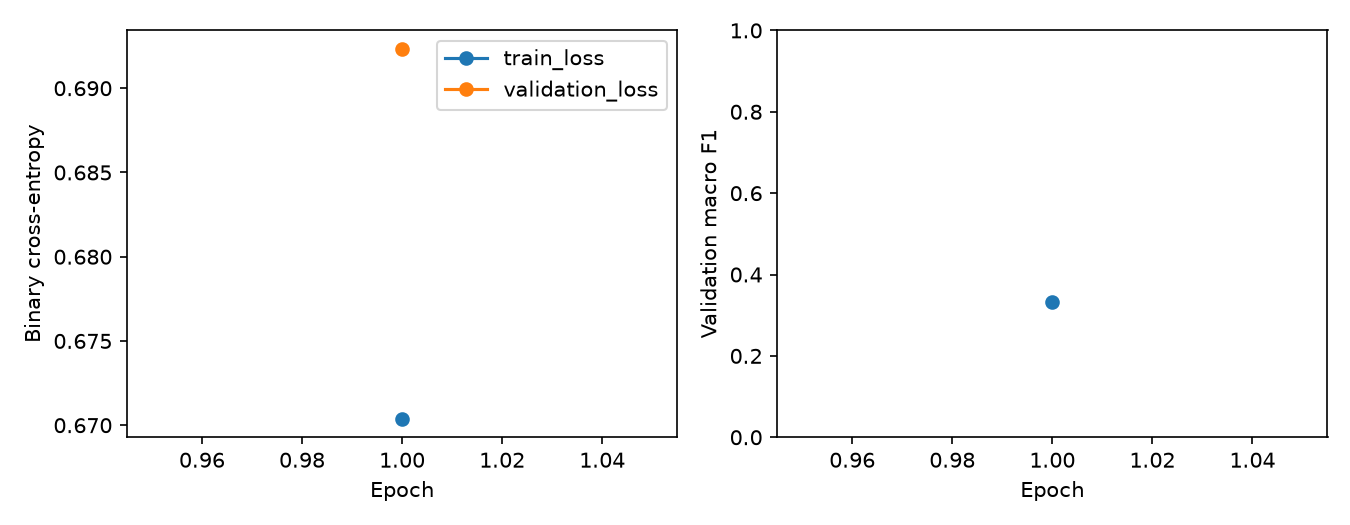

maxpool_mlp/confusion_matrix.png


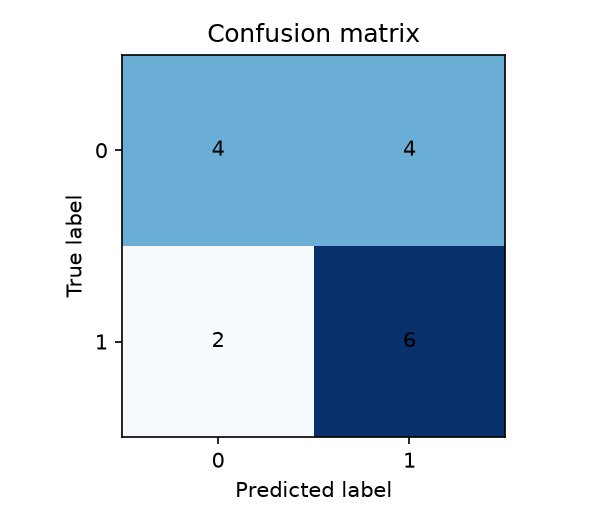

maxpool_mlp/evaluation_curves.png


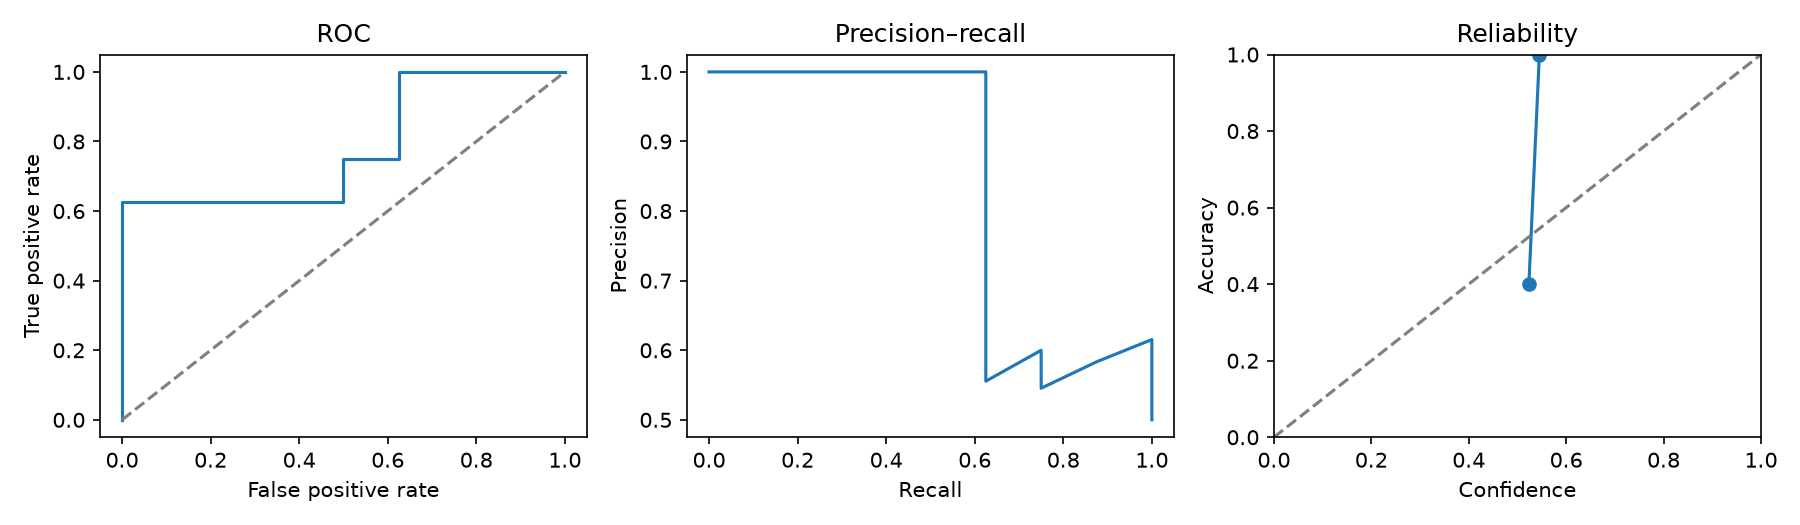

maxpool_mlp/learning_curves.png


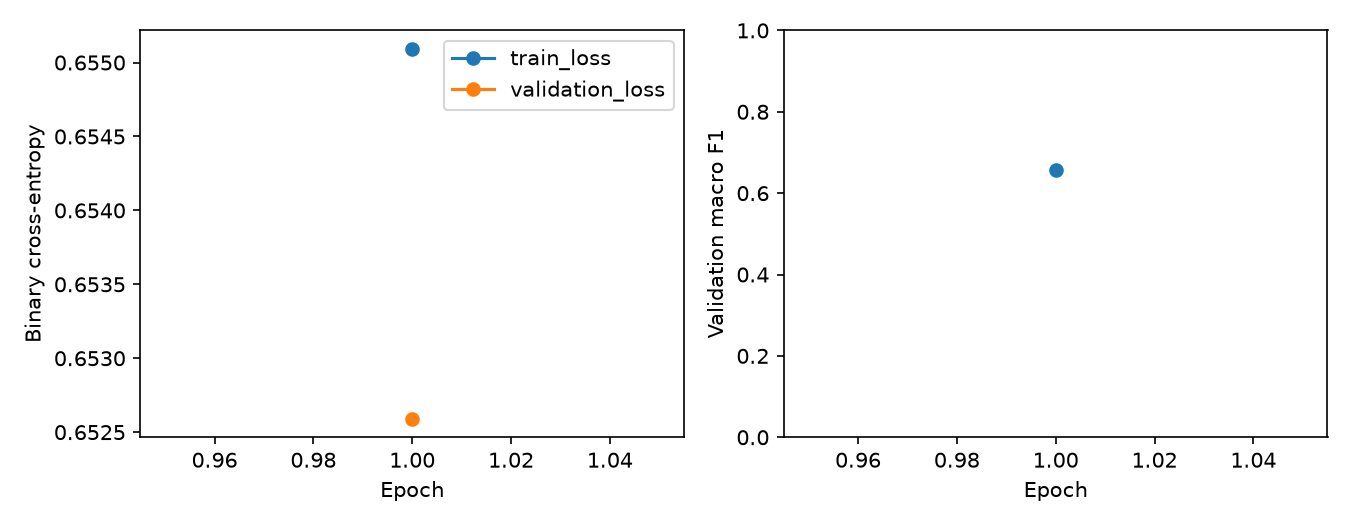

Artifacts:
RUN_LOG.txt
bilstm/confusion_matrix.png
bilstm/curves.json
bilstm/error_candidates_for_manual_review.csv
bilstm/error_review_instructions.json
bilstm/evaluation_curves.png
bilstm/history.json
bilstm/learning_curves.png
bilstm/metrics.json
bilstm/slices.json
bilstm/test_predictions.csv
config.json
data_audit.json
dataset_statistics.json
dilated_cnn/confusion_matrix.png
dilated_cnn/curves.json
dilated_cnn/error_candidates_for_manual_review.csv
dilated_cnn/error_review_instructions.json
dilated_cnn/evaluation_curves.png
dilated_cnn/history.json
dilated_cnn/learning_curves.png
dilated_cnn/metrics.json
dilated_cnn/slices.json
dilated_cnn/test_predictions.csv
maxpool_mlp/confusion_matrix.png
maxpool_mlp/curves.json
maxpool_mlp/error_candidates_for_manual_review.csv
maxpool_mlp/error_review_instructions.json
maxpool_mlp/evaluation_curves.png
maxpool_mlp/history.json
maxpool_mlp/learning_curves.png
maxpool_mlp/metrics.json
maxpool_mlp/slices.json
maxpool_mlp/test_predictions.csv
pai

In [5]:
from IPython.display import display, Image
figures = sorted(p for p in OUTPUT.rglob("*.png") if p.is_file() and
                 (TASK != "cyclegan" or "grids" in p.relative_to(OUTPUT).parts))
for path in figures:
    print(path.relative_to(OUTPUT))
    display(Image(filename=str(path), width=700))
print("Artifacts:")
for path in sorted(OUTPUT.rglob("*")):
    if path.is_file() and path.suffix not in {".pt", ".pth"}:
        print(path.relative_to(OUTPUT))

## Interpretation to write after the real run

Explain the architecture and hyperparameters in your own words. Report the actual data split and hardware. Use generated evidence for metrics and failure analysis. Keep smoke, cloud rehearsal, and college full-run results separate. For the team report, compare all members on the agreed evaluation protocol.